# Riftbound ELO Rankings
Reads from `riftbound_pairings.json` and `players.json`.
Each individual match pairing is treated as a single ELO contest.

In [1]:
import json
from collections import defaultdict

PAIRINGS_FILE = "riftbound_pairings.json"
PLAYERS_FILE  = "players.json"

DEFAULT_RATING = 900.0

K_FACTORS = {
    "release": 8,
    "locals":  16,
    "ss":      40,
}

## ELO Engine

In [10]:
def expected_score(ra, rb):
    return 1.0 / (1.0 + 10 ** ((rb - ra) / 400.0))

def process_pairing(p1_id, p2_id, result, K, ratings):
    """
    Update ratings for a single match pairing.
    result: 'p1' (p1 wins), 'p2' (p2 wins), 'draw'
    """
    ra = ratings.get(p1_id, DEFAULT_RATING)
    rb = ratings.get(p2_id, DEFAULT_RATING)

    ea = expected_score(ra, rb)

    if result == "p1":
        sa, sb = 1.0, 0.0
    elif result == "p2":
        sa, sb = 0.0, 1.0
    else:  # draw
        sa, sb = 0.5, 0.5

    ratings[p1_id] = ra + K * (sa - ea)
    ratings[p2_id] = rb + K * (sb - (1.0 - ea))

def run_elo(pairings_data):
    """
    Process all events in chronological order.
    Returns:
        ratings      - dict of player_id -> current rating
        event_count  - dict of player_id -> number of events participated in
        match_count  - dict of player_id -> number of individual matches played
    """
    # Sort events chronologically
    events = sorted(pairings_data, key=lambda e: e.get("date") or "")

    ratings      = {}
    event_count  = defaultdict(int)
    match_count  = defaultdict(int)
    # New: {player_id: [(date_str, rating), ...]}
    history      = defaultdict(list)

    for event in events:
        tier = event.get("tier", "locals")
        K    = K_FACTORS.get(tier, 16)
        seen_in_event = set()

        for round_ in event.get("rounds", []):
            for pairing in round_.get("pairings", []):
                p1_id  = pairing["p1_id"]
                p2_id  = pairing["p2_id"]
                result = pairing["result"]

                if p1_id not in ratings:
                    ratings[p1_id] = DEFAULT_RATING
                if p2_id not in ratings:
                    ratings[p2_id] = DEFAULT_RATING

                process_pairing(p1_id, p2_id, result, K, ratings)

                match_count[p1_id] += 1
                match_count[p2_id] += 1
                seen_in_event.add(p1_id)
                seen_in_event.add(p2_id)

        # Snapshot ratings after each event for all participants
        for pid in seen_in_event:
            event_count[pid] += 1
            history[pid].append((event["date"], round(ratings[pid], 1)))

    return ratings, event_count, match_count, history

## Load Data & Run

In [12]:
with open(PAIRINGS_FILE) as f:
    pairings_data = json.load(f)

with open(PLAYERS_FILE) as f:
    registry = json.load(f)

ratings, event_count, match_count, history = run_elo(pairings_data)
ranked = sorted(ratings.items(), key=lambda x: -x[1])

print(f"Rated players : {len(ranked)}")
print(f"Events loaded : {len(pairings_data)}")

Rated players : 368
Events loaded : 149


## Display Rankings

In [13]:
from datetime import datetime, timedelta

def get_rating_delta(pid, history, days=7):
    """Rating change over the last N days."""
    if pid not in history or not history[pid]:
        return None
    cutoff = (datetime.today() - timedelta(days=days)).strftime("%Y-%m-%d")
    current = history[pid][-1][1]
    # Find most recent rating before the cutoff
    before = [r for date, r in history[pid] if date <= cutoff]
    if not before:
        return None
    return current - before[-1]

def display_rankings(ranked, registry, event_count, match_count, history,
                     top_n=50, min_events=0, delta_days=7):
    filtered = [
        (pid, rating) for pid, rating in ranked
        if event_count[pid] >= min_events
        and rating != DEFAULT_RATING
    ]
    display = filtered[:top_n] if top_n else filtered

    print(f"{'Rank':<6} {'Player':<28} {'Rating':<10} {f'±{delta_days}d':<10} {'Events':<8} {'Matches'}")
    print("─" * 72)
    for i, (pid, rating) in enumerate(display, 1):
        name    = registry.get(pid, f"Unknown({pid})")
        events  = event_count[pid]
        matches = match_count[pid]
        delta   = get_rating_delta(pid, history, delta_days)
        if delta is None:
            delta_str = "  new"
        elif delta > 0:
            delta_str = f"+{delta:.1f}"
        elif delta < 0:
            delta_str = f"{delta:.1f}"
        else:
            delta_str = "  —"
        print(f"{i:<6} {name:<28} {rating:<10.1f} {delta_str:<10} {events:<8} {matches}")

display_rankings(ranked, registry, event_count, match_count, history, top_n=50)

Rank   Player                       Rating     ±7d        Events   Matches
────────────────────────────────────────────────────────────────────────
1      Nµge                         1198.5     +36.8      28       107
2      Cia Reeves                   1112.0     +74.2      15       60
3      Topazgoose                   1108.4       —        21       79
4      Massive4Head                 1099.4       —        15       38
5      P0werRangerJaune             1071.4     +45.0      7        28
6      ScarletDiva                  1069.9     -10.0      9        34
7      LastHuman                    1066.6     +25.5      12       40
8      F2ng                         1037.4       —        11       37
9      Whymsy                       1018.7     -45.1      13       47
10     Rubadubblub                  1017.9     +51.2      13       40
11     PolePole                     1012.6     +71.1      12       43
12     batedlawyer884               1004.4     +3.7       13       51
13     Loca

## Look Up a Player

In [14]:
def player_history(name_query, pairings_data, registry, ratings, event_count, match_count, ranked):
    """Show a player's full tournament history including standings and match results."""
    
    # Find player ID from name
    name_to_id = {v.lower(): k for k, v in registry.items()}
    pid = name_to_id.get(name_query.lower())
    
    if not pid:
        # Try partial match
        matches = [(k, v) for v, k in name_to_id.items() if name_query.lower() in v]
        if not matches:
            print(f"No player found matching '{name_query}'")
            return
        if len(matches) > 1:
            print(f"Multiple matches found:")
            for k, v in matches:
                print(f"  {registry.get(k, k)}")
            return
        pid, _ = matches[0]

    name     = registry.get(pid, f"Unknown({pid})")
    rating   = ratings.get(pid, DEFAULT_RATING)
    rank     = next((i + 1 for i, (p, _) in enumerate(ranked) if p == pid), None)
    events   = event_count[pid]
    matches  = match_count[pid]

    print(f"{'═' * 60}")
    print(f"  {name}")
    print(f"{'═' * 60}")
    print(f"  ELO Rating  : {rating:.1f}   (Rank #{rank})")
    print(f"  Events      : {events}")
    print(f"  Matches     : {matches}")
    print()

    # Walk events chronologically
    sorted_events = sorted(pairings_data, key=lambda e: e.get("date") or "")
    
    total_wins = total_losses = total_draws = 0

    for event in sorted_events:
        # Check if player appeared in this event
        player_rounds = []
        for round_ in event.get("rounds", []):
            round_pairings = [
                p for p in round_.get("pairings", [])
                if p["p1_id"] == pid or p["p2_id"] == pid
            ]
            if round_pairings:
                player_rounds.append((round_["round"], round_pairings))

        if not player_rounds:
            continue

        # Get standing for this event
        standing = next(
            (s for s in event.get("standings", []) if s["player_id"] == pid),
            None
        )

        # Header
        placement = f"  #{standing['rank']} ({standing['record']})" if standing else ""
        print(f"  ── {event['date']}  {event['name']}  [{event.get('tier','?')}]{placement}")

        # Match results
        for round_num, pairings in player_rounds:
            for p in pairings:
                if p["p1_id"] == pid:
                    opponent = p["p2"]
                    result   = p["result"]
                    outcome  = "W" if result == "p1" else ("L" if result == "p2" else "D")
                else:
                    opponent = p["p1"]
                    result   = p["result"]
                    outcome  = "W" if result == "p2" else ("L" if result == "p1" else "D")

                if outcome == "W":
                    symbol = "✓"
                    total_wins += 1
                elif outcome == "L":
                    symbol = "✗"
                    total_losses += 1
                else:
                    symbol = "~"
                    total_draws += 1

                print(f"      R{round_num}  {symbol} {outcome}  vs  {opponent}")

        print()

    # Career summary
    total = total_wins + total_losses + total_draws
    win_rate = (total_wins / total * 100) if total else 0
    print(f"{'─' * 60}")
    print(f"  Career record  : {total_wins}W / {total_losses}L / {total_draws}D  ({win_rate:.1f}% win rate)")
    print(f"{'═' * 60}")


# Example usage:
player_history("Gormfaobhar", pairings_data, registry, ratings, event_count, match_count, ranked)


════════════════════════════════════════════════════════════
  Gormfaobhar
════════════════════════════════════════════════════════════
  ELO Rating  : 1002.0   (Rank #14)
  Events      : 1
  Matches     : 7

  ── 2026-03-07  Saturday Afternoon Summoner Skirmish - March  [ss]  #1 (5-0-2)
      R1  ✓ W  vs  SilverPhoenix206
      R2  ✓ W  vs  MuffinicK
      R3  ~ D  vs  PolePole
      R4  ~ D  vs  Cannasquawk
      R5  ✓ W  vs  GKT SHAIYEN 
      R6  ✓ W  vs  P0werRangerJaune
      R7  ✓ W  vs  PolePole

────────────────────────────────────────────────────────────
  Career record  : 5W / 0L / 2D  (71.4% win rate)
════════════════════════════════════════════════════════════


## Head-to-Head Record

In [6]:
def head_to_head(name_a, name_b, pairings_data, registry):
    """Show all matches between two players."""
    # Build reverse lookup: name -> id
    name_to_id = {v.lower(): k for k, v in registry.items()}
    id_a = name_to_id.get(name_a.lower())
    id_b = name_to_id.get(name_b.lower())

    if not id_a:
        print(f"Player not found: {name_a}")
        return
    if not id_b:
        print(f"Player not found: {name_b}")
        return

    wins_a, wins_b, draws = 0, 0, 0
    matches = []

    for event in sorted(pairings_data, key=lambda e: e.get("date") or ""):
        for round_ in event.get("rounds", []):
            for pairing in round_.get("pairings", []):
                ids = {pairing["p1_id"], pairing["p2_id"]}
                if id_a in ids and id_b in ids:
                    result = pairing["result"]
                    if result == "draw":
                        outcome = "Draw"
                        draws += 1
                    elif (result == "p1" and pairing["p1_id"] == id_a) or \
                         (result == "p2" and pairing["p2_id"] == id_a):
                        outcome = f"{name_a} wins"
                        wins_a += 1
                    else:
                        outcome = f"{name_b} wins"
                        wins_b += 1
                    matches.append((event["date"], event["name"], event["location"], round_["round"], outcome))

    if not matches:
        print(f"No matches found between {name_a} and {name_b}")
        return

    print(f"Head-to-head: {name_a} vs {name_b}")
    print(f"  {name_a}: {wins_a}  |  {name_b}: {wins_b}  |  Draws: {draws}")
    print()
    for date, event_name, location, rnd, outcome in matches:
        print(f"  {date}  R{rnd}  {event_name} ({location})")
        print(f"          → {outcome}")

# Example usage:
head_to_head("Nµge", "F2ng", pairings_data, registry)

Head-to-head: Nµge vs F2ng
  Nµge: 1  |  F2ng: 1  |  Draws: 0

  2025-12-14  R4  Sunday Summoner Skirmish - December (Underworld Gaming)
          → F2ng wins
  2026-02-08  R3  Sunday Afternoon Spiritforged Pre-Rift Event (ReRoll Games)
          → Nµge wins


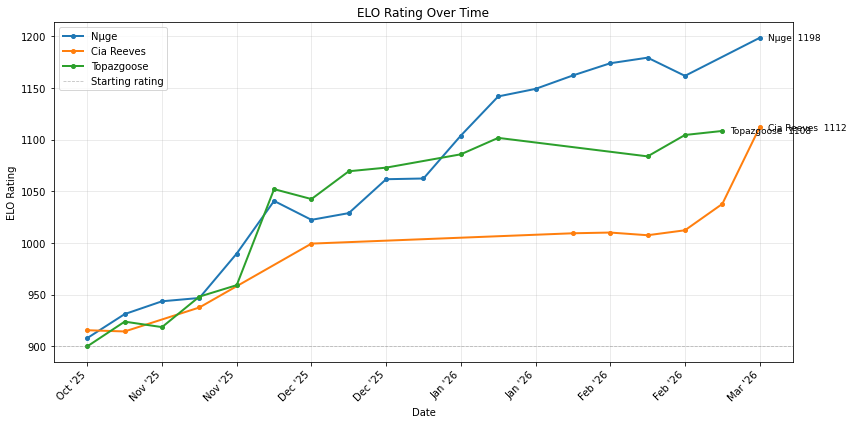

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

def plot_rating_trend(name_queries, pairings_data, registry, history, weekly=True):
    """
    Plot ELO rating over time for one or more players.
    name_queries: string or list of strings
    weekly: if True, resample to weekly data points
    """
    if isinstance(name_queries, str):
        name_queries = [name_queries]

    name_to_id = {v.lower(): k for k, v in registry.items()}

    fig, ax = plt.subplots(figsize=(12, 6))

    for name_query in name_queries:
        pid = name_to_id.get(name_query.lower())
        if not pid:
            # Partial match
            matches = [(k, v) for v, k in name_to_id.items() if name_query.lower() in v]
            if not matches:
                print(f"Player not found: {name_query}")
                continue
            pid, _ = matches[0]

        name = registry.get(pid, pid)
        snapshots = history.get(pid, [])
        if not snapshots:
            print(f"No history for {name}")
            continue

        dates   = [datetime.strptime(d, "%Y-%m-%d") for d, _ in snapshots]
        ratings_over_time = [r for _, r in snapshots]

        if weekly:
            # Resample: for each week, take the last rating in that week
            week_map = {}
            for date, rating in zip(dates, ratings_over_time):
                # ISO week key
                week_key = date - timedelta(days=date.weekday())  # Monday of that week
                week_map[week_key] = rating
            dates   = sorted(week_map.keys())
            ratings_over_time = [week_map[d] for d in dates]

        ax.plot(dates, ratings_over_time, marker="o", markersize=4, linewidth=2, label=name)
        # Annotate final rating
        ax.annotate(
            f"{name}  {ratings_over_time[-1]:.0f}",
            xy=(dates[-1], ratings_over_time[-1]),
            xytext=(8, 0),
            textcoords="offset points",
            fontsize=9,
            va="center",
        )

    # Reference line at default rating
    ax.axhline(DEFAULT_RATING, color="grey", linestyle="--", linewidth=0.8, alpha=0.5, label="Starting rating")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
    plt.xticks(rotation=45, ha="right")
    ax.set_xlabel("Date")
    ax.set_ylabel("ELO Rating")
    ax.set_title("ELO Rating Over Time")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Single player:
#plot_rating_trend("Whymsy", pairings_data, registry, history)

# Multiple players for comparison:
plot_rating_trend(["Nµge", "Cia Reeves", "Topazgoose"], pairings_data, registry, history)